## Section 1: Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/lending_club_loan_two.csv')

In [ ]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

**Creating a countplot for observing Loan Status**

<Axes: xlabel='loan_status', ylabel='count'>

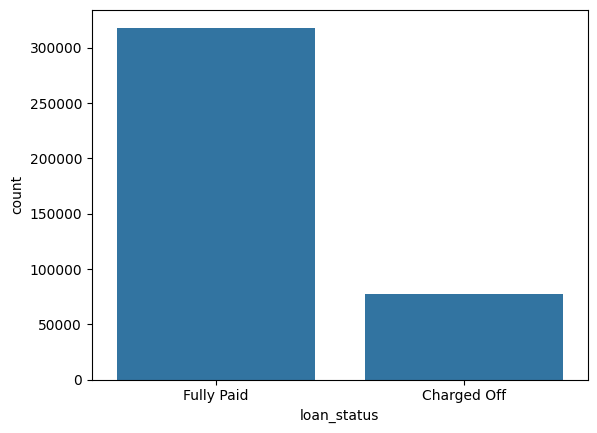

In [ ]:
sns.countplot(x='loan_status',data=df)

**Histogram of the loan amount column**

/tmp/ipykernel_35413/1068575699.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['loan_amnt'], kde = False)


<Axes: xlabel='loan_amnt'>

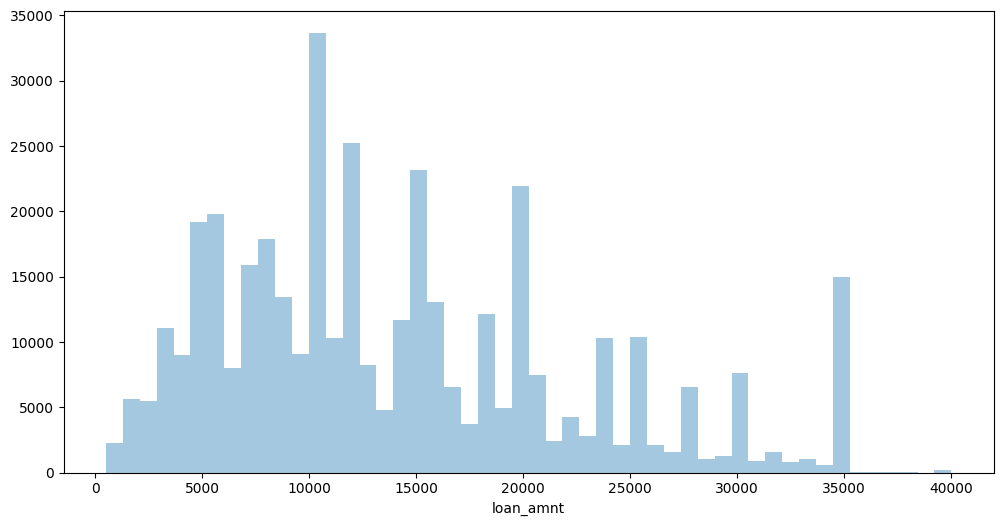

In [ ]:
plt.figure(figsize=(12,6))
sns.distplot(df['loan_amnt'], kde = False)

**Explore correlation between the continuous feature variables**

In [ ]:
df.corr(numeric_only=True)

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
loan_amnt,1.000000,0.168921,0.953929,0.336887,0.016636,0.198556,-0.077779,0.328320,0.099911,0.223886,0.222315,-0.106539
int_rate,0.168921,1.000000,0.162758,-0.056771,0.079038,0.011649,0.060986,-0.011280,0.293659,-0.036404,-0.082583,0.057450
installment,0.953929,0.162758,1.000000,0.330381,0.015786,0.188973,-0.067892,0.316455,0.123915,0.202430,0.193694,-0.098628
annual_inc,0.336887,-0.056771,0.330381,1.000000,-0.081685,0.136150,-0.013720,0.299773,0.027871,0.193023,0.236320,-0.050162
dti,0.016636,0.079038,0.015786,-0.081685,1.000000,0.136181,-0.017639,0.063571,0.088375,0.102128,-0.025439,-0.014558
open_acc,0.198556,0.011649,0.188973,0.136150,0.136181,1.000000,-0.018392,0.221192,-0.131420,0.680728,0.109205,-0.027732
pub_rec,-0.077779,0.060986,-0.067892,-0.013720,-0.017639,-0.018392,1.000000,-0.101664,-0.075910,0.019723,0.011552,0.699408
revol_bal,0.328320,-0.011280,0.316455,0.299773,0.063571,0.221192,-0.101664,1.000000,0.226346,0.191616,0.194925,-0.124532
revol_util,0.099911,0.293659,0.123915,0.027871,0.088375,-0.131420,-0.075910,0.226346,1.000000,-0.104273,0.007514,-0.086751
total_acc,0.223886,-0.036404,0.202430,0.193023,0.102128,0.680728,0.019723,0.191616,-0.104273,1.000000,0.381072,0.042035


**Creating a heatmap to visualize the correlation**

<Axes: >

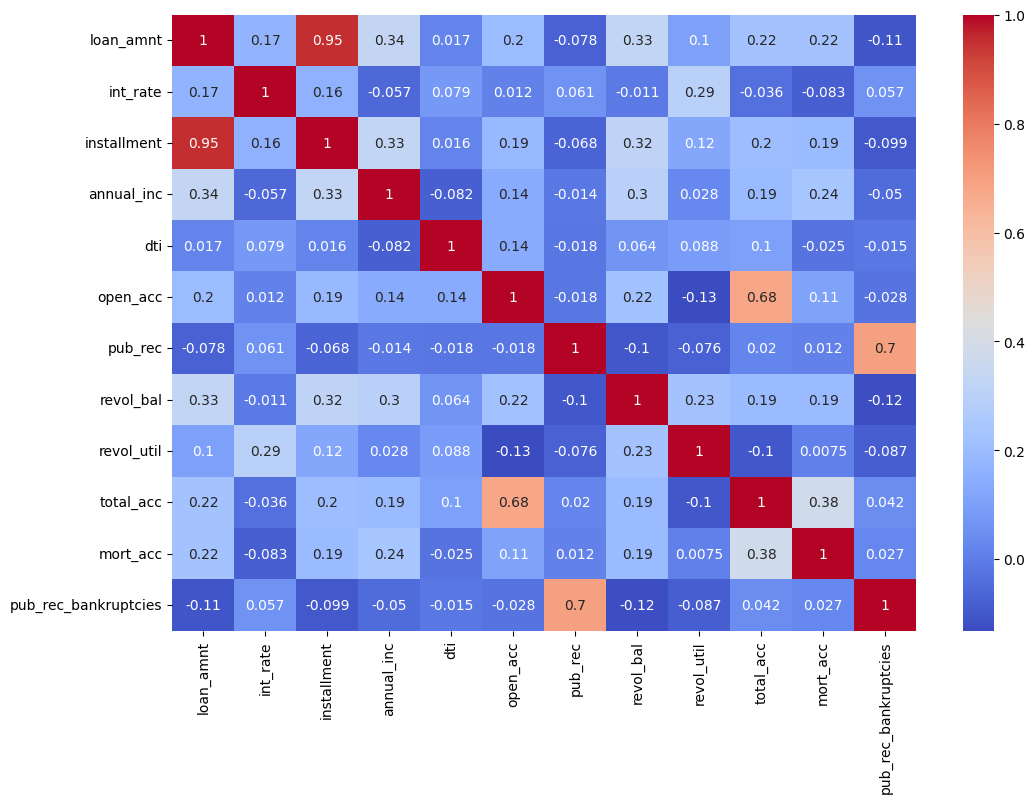

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot = True, cmap = 'coolwarm')
#plt.ylim(10,0)

**loan_amount has about perfect correlation with installment. So a scatterplot between these two**

<Axes: xlabel='installment', ylabel='loan_amnt'>

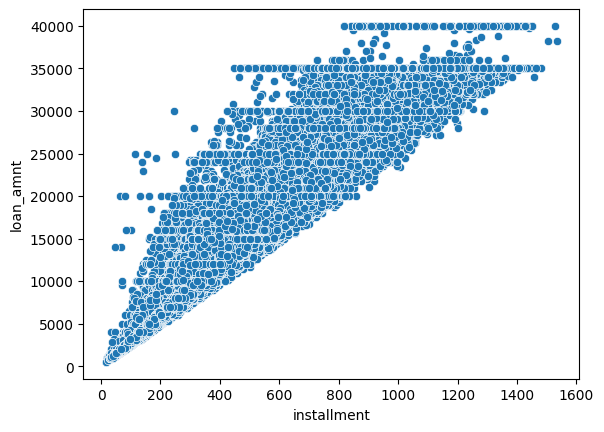

In [ ]:
sns.scatterplot(x='installment',y='loan_amnt',data=df)

**Create a Boxplot showing the relationship between the loan_status and the loan_amount**

<Axes: xlabel='loan_status', ylabel='loan_amnt'>

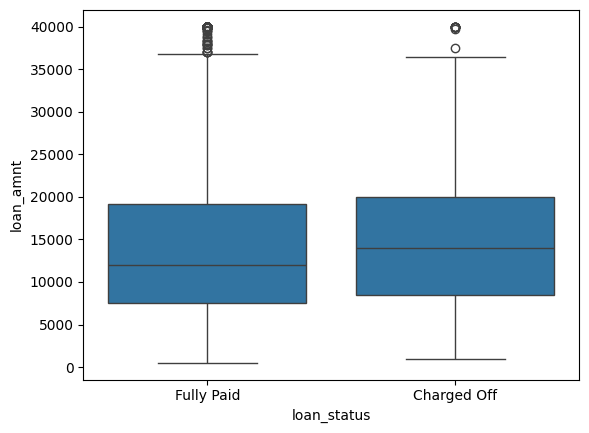

In [ ]:
sns.boxplot(x='loan_status',y='loan_amnt',data=df)

**Calculate the summary statistics for the loan amount, grouped by the loan status**

In [ ]:
df.groupby('loan_status')['loan_amnt'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,77673.0,15126.300967,8505.090557,1000.0,8525.0,14000.0,20000.0,40000.0
Fully Paid,318357.0,13866.878771,8302.319699,500.0,7500.0,12000.0,19225.0,40000.0


The mean of charged off loans are slightly higher than the Fully Paid loans

In [ ]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'title',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'application_type',
       'mort_acc', 'pub_rec_bankruptcies', 'address'],
      dtype='object')

**Let's explore the Grade and Subgrade columns that LendingClub attributes to the loans. What are the unique possible grades and subgrades**

In [ ]:
grade_list = list(df['grade'].unique())
grade_list

['B', 'A', 'C', 'E', 'D', 'F', 'G']

In [ ]:
sub_grade_list = list(df['sub_grade'].unique())
sub_grade_list

['B4',
 'B5',
 'B3',
 'A2',
 'C5',
 'C3',
 'A1',
 'B2',
 'C1',
 'A5',
 'E4',
 'A4',
 'A3',
 'D1',
 'C2',
 'B1',
 'D3',
 'D5',
 'D2',
 'E1',
 'E2',
 'E5',
 'F4',
 'E3',
 'D4',
 'G1',
 'F5',
 'G2',
 'C4',
 'F1',
 'F3',
 'G5',
 'G4',
 'F2',
 'G3']

**Create a countplot per grade with hue = loan_status**

<Axes: xlabel='grade', ylabel='count'>

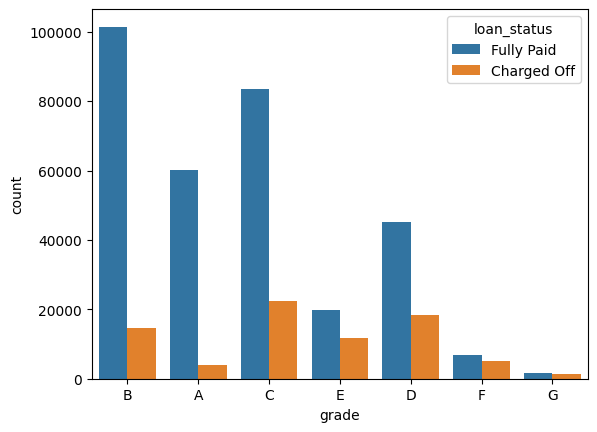

In [ ]:
sns.countplot(x='grade',hue='loan_status',data=df)

**Display a countplot per sub_grade**

/tmp/ipykernel_35413/2261387622.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sub_grade',data=df,


<Axes: xlabel='sub_grade', ylabel='count'>

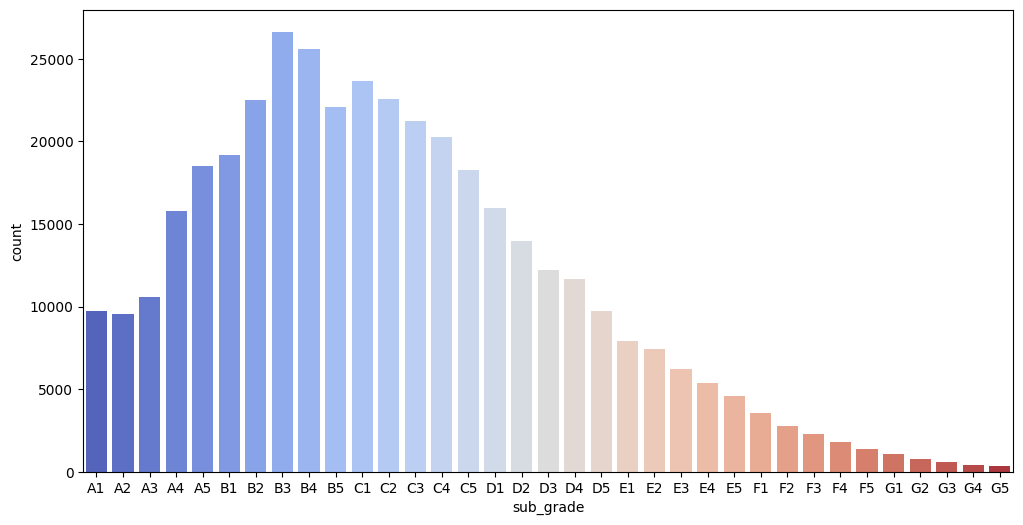

In [ ]:
plt.figure(figsize=(12,6)) #resizing the plot
subgrade_order = sorted(list(df['sub_grade'].unique())) #sorting the subgrade
sns.countplot(x='sub_grade',data=df,
              order = subgrade_order, palette= 'coolwarm')

**with hue = loan_status**

<Axes: xlabel='sub_grade', ylabel='count'>

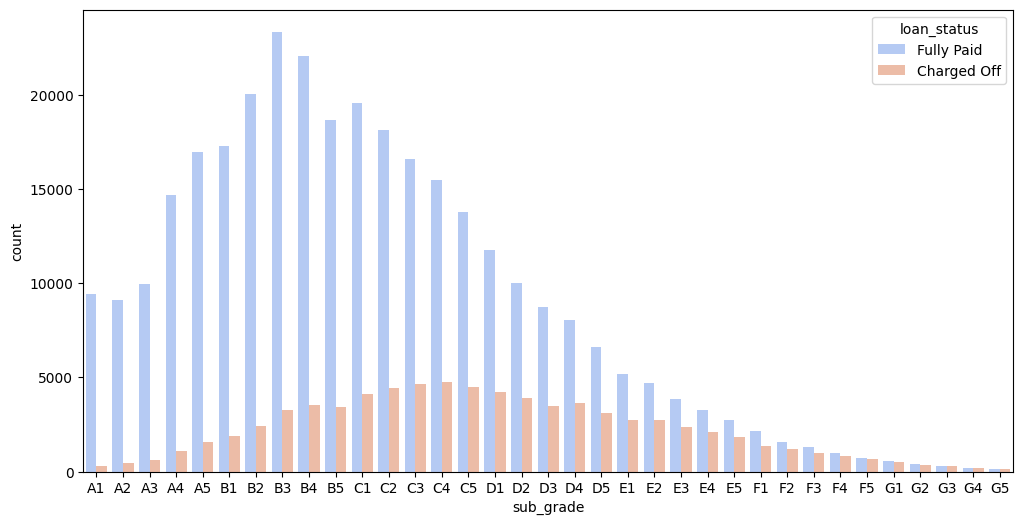

In [ ]:
plt.figure(figsize=(12,6)) #resizing the plot
subgrade_order = sorted(list(df['sub_grade'].unique())) #sorting the subgrade
sns.countplot(x='sub_grade',data=df,
              order = subgrade_order, palette= 'coolwarm',
              hue = 'loan_status')

**It looks like F and G subgrades don't get paid back that often. Isolate and create a countplot for these 2 grades only**

<Axes: xlabel='sub_grade', ylabel='count'>

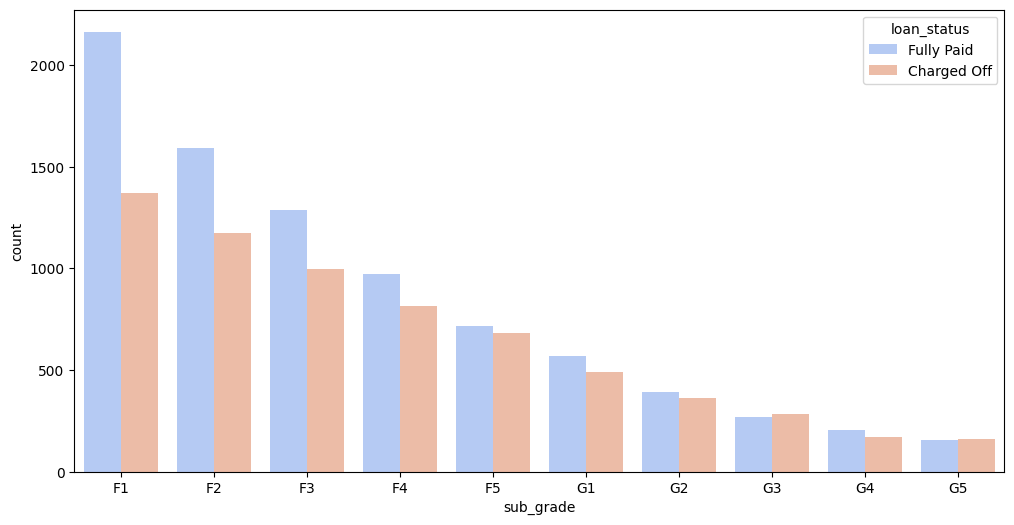

In [ ]:
f_and_g = df[(df['grade'] == 'F') | (df['grade'] == 'G')]

plt.figure(figsize=(12,6)) #resizing the plot
subgrade_order = sorted(list(f_and_g['sub_grade'].unique())) #sorting the subgrade
sns.countplot(x='sub_grade',data=df,
              order = subgrade_order, palette= 'coolwarm',
              hue = 'loan_status')

**Create a new column called 'loan_repaid' which will contain a 1 if the loan status was fully paid and a 0 if it was charged off**

In [ ]:
df['loan_repaid'] = df['loan_status'].map({'Fully Paid': 1, 'Charged Off': 0})

In [ ]:
df[['loan_repaid', 'loan_status']]

,loan_repaid,loan_status
0,1,Fully Paid
1,1,Fully Paid
2,1,Fully Paid
3,1,Fully Paid
4,0,Charged Off
...,...,...
396025,1,Fully Paid
396026,1,Fully Paid
396027,1,Fully Paid
396028,1,Fully Paid


**Creating a correlation table based on the loan_repaid column**

In [ ]:
df.corr(numeric_only=True)['loan_repaid']

,loan_repaid
loan_amnt,-0.059836
int_rate,-0.247758
installment,-0.041082
annual_inc,0.053432
dti,-0.062413
open_acc,-0.028012
pub_rec,-0.019933
revol_bal,0.010892
revol_util,-0.082373
total_acc,0.017893


**Create a barplot showing the correlation of the numeric features to the new loan_repaid column**

<Axes: ylabel='loan_repaid'>

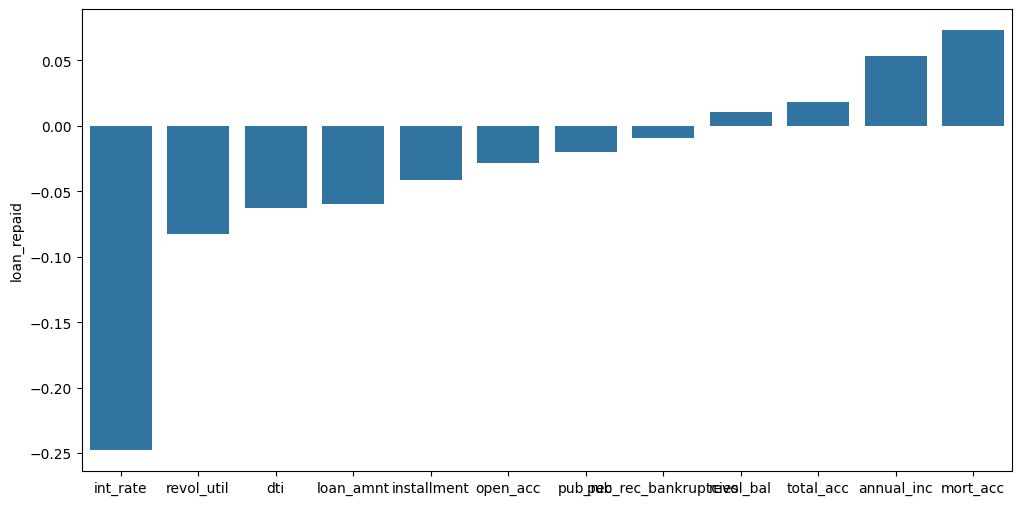

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(df.corr(numeric_only=True)['loan_repaid'][:-1].sort_values())

## Section 2: Data Preprocessing

**length of the dataframe**

In [ ]:
len(df)

396030

**Create a series that displays the total count of missing values per column**

In [ ]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_title,22927
emp_length,18301
home_ownership,0
annual_inc,0


**Convert this series to be in term of percentage of the total DataFrame**

In [ ]:
(df.isnull().sum()/len(df))*100

,0
loan_amnt,0.000000
term,0.000000
int_rate,0.000000
installment,0.000000
grade,0.000000
sub_grade,0.000000
emp_title,5.789208
emp_length,4.621115
home_ownership,0.000000
annual_inc,0.000000


**Examine emp_title and emp_length to see whether its okay to frop these two columns**

**How many unique employment job titles are there**

In [ ]:
df['emp_title'].nunique()

173105

In [ ]:
df['emp_title'].value_counts()

,count
emp_title,
Teacher,4389
Manager,4250
Registered Nurse,1856
RN,1846
Supervisor,1830
...,...
OMIV Supervisor,1
"SVP, Technology",1
sikorsky,1


There are too many variables to convert these into a dummy variable column. So, removing this 'emp_title' column

In [ ]:
df = df.drop('emp_title', axis = 1)

**Create a countplot of the emp_length feature column and sort the order of the values!**

In [ ]:
sorted(df['emp_length'].dropna().unique())

['1 year',
 '10+ years',
 '2 years',
 '3 years',
 '4 years',
 '5 years',
 '6 years',
 '7 years',
 '8 years',
 '9 years',
 '< 1 year']

In [ ]:
emp_length_order = ['1 year',
 '< 1 year',
 '2 years',
 '3 years',
 '4 years',
 '5 years',
 '6 years',
 '7 years',
 '8 years',
 '9 years',
 '10+ years']

<Axes: xlabel='emp_length', ylabel='count'>

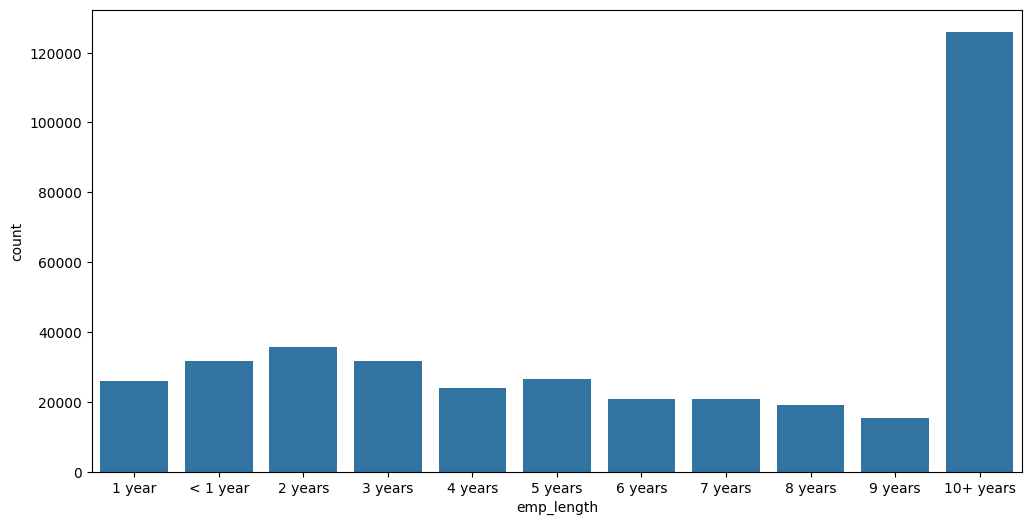

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='emp_length',data=df, order = emp_length_order)

**hue = loan_status**

<Axes: xlabel='emp_length', ylabel='count'>

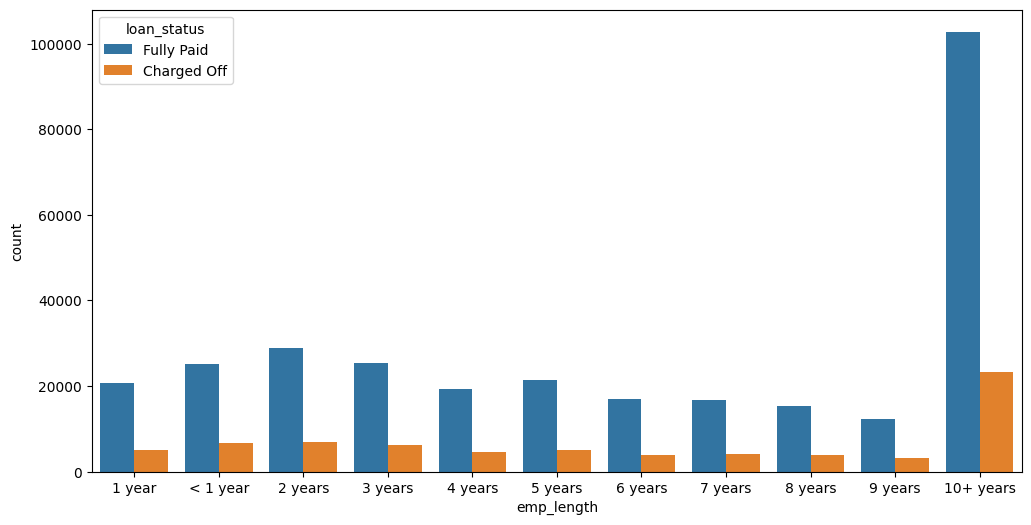

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='emp_length',data=df, order = emp_length_order,
              hue = 'loan_status')

**percent of people that don't pay back their loan per employment category**

In [ ]:
emp_co = df[df['loan_status'] == 'Charged Off'].groupby('emp_length').count()['loan_status']

In [ ]:
emp_fp = df[df['loan_status'] == 'Fully Paid'].groupby('emp_length').count()['loan_status']

In [ ]:
emp_len = emp_co/(emp_co + emp_fp)

<Axes: xlabel='emp_length'>

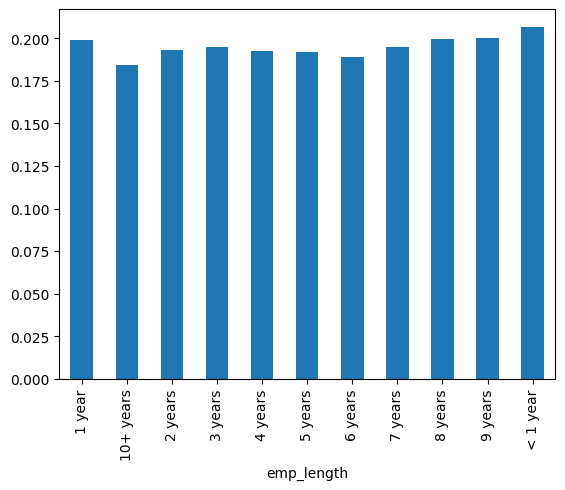

In [ ]:
emp_len.plot(kind = 'bar')

Charge_off rates are extremely similar. So we need to drop this column.

In [ ]:
df = df.drop('emp_length', axis = 1)

In [ ]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
home_ownership,0
annual_inc,0
verification_status,0
issue_d,0


**Review the title column vs the purpose column. Is this repeated information?**

In [ ]:
df['title'].value_counts()

,count
title,
Debt consolidation,152472
Credit card refinancing,51487
Home improvement,15264
Other,12930
Debt Consolidation,11608
...,...
creditcardrefi,1
Debt/Home,1
Peace Of Mind Loan,1


there are so many varieties of title and purpose. So dropping thses two columns!

In [ ]:
df = df.drop(['title', 'purpose'], axis = 1)

In [ ]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
home_ownership,0
annual_inc,0
verification_status,0
issue_d,0


In [ ]:
df['mort_acc'].value_counts()

,count
mort_acc,
0.0,139777
1.0,60416
2.0,49948
3.0,38049
4.0,27887
5.0,18194
6.0,11069
7.0,6052
8.0,3121


This represents the number of mortgage accounts.

**Correlation with the mortgage account column**

In [ ]:
df.corr(numeric_only=True)['mort_acc'].sort_values()

,mort_acc
int_rate,-0.082583
dti,-0.025439
revol_util,0.007514
pub_rec,0.011552
pub_rec_bankruptcies,0.027239
loan_repaid,0.073111
open_acc,0.109205
installment,0.193694
revol_bal,0.194925
loan_amnt,0.222315


'total_acc' feature correlates with 'mort_acc'.

We will group the dataframe by total_acc and calculate the mean value for the mort_acc per the total_acc entry.

In [ ]:
df.groupby('total_acc')['mort_acc'].mean()

,mort_acc
total_acc,
2.0,0.000000
3.0,0.052023
4.0,0.066743
5.0,0.103289
6.0,0.151293
...,...
124.0,1.000000
129.0,1.000000
135.0,3.000000


In [ ]:
total_acc_avg = df.groupby('total_acc')['mort_acc'].mean()

Meaning there is a direct relation in between the number of total_acc and mort_acc. So, filling up the missing values in mort_acc using the information we found just now:

**filling up the missing values in mort_acc**

In [ ]:
def fill_mort_acc(total_acc, mort_acc):
  if np.isnan(mort_acc):
    return total_acc_avg[total_acc]
  else:
    return mort_acc

In [ ]:
df['mort_acc'] = df.apply(lambda x: fill_mort_acc(x['total_acc'], x['mort_acc']), axis = 1)

In [ ]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
home_ownership,0
annual_inc,0
verification_status,0
issue_d,0


In [ ]:
len(df)

396030

Compared to our total number of rows the missing values in 'revol_util' and 'pub_rec_bankruptcies' are really small. So dropping the rows those hae these missing values!

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
home_ownership,0
annual_inc,0
verification_status,0
issue_d,0


No missing values in the dataFrame!!

**List all the columns that are currently non-numeric**

In [ ]:
df.select_dtypes(['object']).columns

Index(['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status',
       'issue_d', 'loan_status', 'earliest_cr_line', 'initial_list_status',
       'application_type', 'address'],
      dtype='object')

**Convert the term feature into either a 36 or 60 integer numeric data type using .apply() or .map()**

In [ ]:
df['term'].value_counts()

,count
term,
36 months,301247
60 months,93972


In [ ]:
df['term'] = df['term'].apply(lambda term: int(term[:3]))

**As grade is a part of subgrade, we will drop this grade feature!**

In [ ]:
df = df.drop('grade', axis = 1)

**Convert the subgrade into dummy variables**

In [ ]:
dummies = pd.get_dummies(df['sub_grade'], drop_first=True)

In [ ]:
df = pd.concat([df.drop('sub_grade', axis = 1), dummies], axis = 1)

In [ ]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'dti',
       'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'initial_list_status', 'application_type', 'mort_acc',
       'pub_rec_bankruptcies', 'address', 'loan_repaid', 'A2', 'A3', 'A4',
       'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1', 'C2', 'C3', 'C4', 'C5', 'D1',
       'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3',
       'F4', 'F5', 'G1', 'G2', 'G3', 'G4', 'G5'],
      dtype='object')

**verification_status, application_type, initial_list_status- convert these column into dummy variables and concatenate them with the original dataFrame**

In [ ]:
dummies = pd.get_dummies(df[['verification_status', 'application_type', 'initial_list_status']],
                         drop_first=True)
df = pd.concat([df.drop(['verification_status', 'application_type', 'initial_list_status'],
                        axis = 1), dummies], axis = 1)

In [ ]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'home_ownership',
       'annual_inc', 'issue_d', 'loan_status', 'dti', 'earliest_cr_line',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'mort_acc', 'pub_rec_bankruptcies', 'address', 'loan_repaid', 'A2',
       'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1', 'C2', 'C3', 'C4',
       'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1',
       'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3', 'G4', 'G5',
       'verification_status_Source Verified', 'verification_status_Verified',
       'application_type_INDIVIDUAL', 'application_type_JOINT',
       'initial_list_status_w'],
      dtype='object')

**home ownership**

In [ ]:
df['home_ownership'].value_counts()

,count
home_ownership,
MORTGAGE,198022
RENT,159395
OWN,37660
OTHER,110
NONE,29
ANY,3


**Convert these to dummy variables but replace NONE & ANY with OTHER, so that we end up with just 4 categories MORTGAGE, RENT, OWN & OTHER. Then concatenate them with the original dataframe. Remember to set drop_first = True and to drop the original columns**

In [ ]:
df['home_ownership'].replace(['NONE', 'ANY'], 'OTHER', inplace=True)

/tmp/ipykernel_35413/3762112415.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['home_ownership'].replace(['NONE', 'ANY'], 'OTHER', inplace=True)


In [ ]:
df['home_ownership'].value_counts()

,count
home_ownership,
MORTGAGE,198022
RENT,159395
OWN,37660
OTHER,142


In [ ]:
dummies = pd.get_dummies(df['home_ownership'], drop_first=True)
df = pd.concat([df.drop('home_ownership', axis = 1), dummies], axis = 1)

**address**

**Let's feature engineer a zip code column from the address in the data set. Create a column called 'zip_code' that extracts the zip code from the address column**

In [ ]:
df['zip_code'] = df['address'].apply(lambda address: address[-5:])

In [ ]:
df = df.drop('address', axis = 1)

In [ ]:
df['zip_code'].value_counts()

,count
zip_code,
70466,56880
22690,56413
30723,56402
48052,55811
00813,45725
29597,45393
05113,45300
11650,11210
93700,11126


In [ ]:
dummies = pd.get_dummies(df['zip_code'], drop_first=True)
df = pd.concat([df.drop('zip_code', axis = 1), dummies], axis = 1)

The issue_d column represents the month on which the loan was funded. Dropping this column:

In [ ]:
df = df.drop('issue_d', axis= 1)

**earliest_cr_line**

In [ ]:
df['earliest_cr_line'] = df['earliest_cr_line'].apply(lambda date: int(date[-4:]))

In [ ]:
df['earliest_cr_line'].value_counts()

,count
earliest_cr_line,
2000,29302
2001,29031
1999,26444
2002,25849
2003,23623
...,...
1950,3
1951,3
1953,2


**Dropping the loan_status column**

In [ ]:
df = df.drop('loan_status', axis = 1)

## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop('loan_repaid', axis = 1)
y = df['loan_repaid']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

## Normalizing the Data

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()

In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Creating the Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

**Checking the shape of the dataFrame to select the number of neurons for our model**

In [ ]:
model = Sequential()

model.add(Dense(78, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(39, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(19, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam')

In [ ]:
model.fit(x = X_train, y = y_train, epochs = 25, batch_size = 256,
          validation_data = (X_test, y_test))

Epoch 1/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.2971 - val_loss: 0.2652
Epoch 2/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.2648 - val_loss: 0.2628
Epoch 3/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2629 - val_loss: 0.2624
Epoch 4/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2617 - val_loss: 0.2619
Epoch 5/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2608 - val_loss: 0.2617
Epoch 6/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2605 - val_loss: 0.2620
Epoch 7/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.2602 - val_loss: 0.2616
Epoch 8/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2599 - val_loss: 0.2613
Epoch 9/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.2596 - val_loss: 0.2613
Epoch 10/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.2595 - val_loss: 0.2614
Epoch 11/25
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2594 - val_loss: 0.2611
Epoch 12/25
1236/1236 ━━━━━━━━

<Axes: >

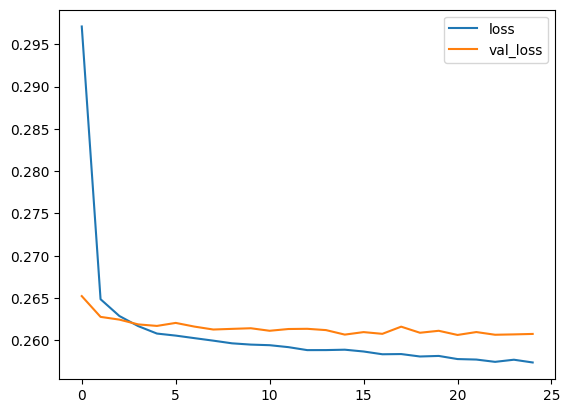

In [ ]:
losses = pd.DataFrame(model.history.history)
losses.plot()

**Create predictions from X_test set and display a classification report and confusion matrix for the X_test set.**

In [ ]:
predictions = (model.predict(X_test) > 0.5).astype(int)

2471/2471 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      0.43      0.60     15658
           1       0.88      1.00      0.93     63386

    accuracy                           0.89     79044
   macro avg       0.93      0.72      0.77     79044
weighted avg       0.90      0.89      0.87     79044



In [ ]:
print(confusion_matrix(y_test, predictions))

[[ 6801  8857]
 [   67 63319]]
